## Máster en Big Data y Data Science

### Metodologías de gestión y diseño de proyectos de big data

#### AP2 - Modelado y evaluación

---

En esta libreta se realiza la experimentación para generación del modelo de predicción objetivo del proyecto y la evaluación del mismo.
La versión del dataset a utilizar es la obtenida a partir de las operaciones de transformación.

In [1]:
# Se importan las librerías necesarias y se suprimen las advertencias
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.dummy import DummyClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore',category=FutureWarning)
warnings.filterwarnings('ignore',category=UserWarning)

In [2]:
# Lectura de los datos
df = pd.read_csv('../data/processed/datos_integrados.csv')
df.head(5)

,id_cliente,importe_solicitado,duracion_credito,situacion_vivienda,ingresos,objetivo_credito,pct_ingreso,tasa_interes,falta_pago,antiguedad_cliente,...,gastos_ult_12m,genero,limite_credito_tc,nivel_educativo,operaciones_ult_12m,personas_a_cargo,estado_civil_N,estado_credito_N,antiguedad_empleado_N,edad_N
0,713061558.0,35000,3,ALQUILER,59000,PERSONAL,0.59,16.02,Y,36.0,...,1088.0,M,4010.0,UNIVERSITARIO_COMPLETO,24.0,2.0,C,C,NaN,menor_25
1,768805383.0,1000,2,PROPIA,9600,EDUCACIÓN,0.10,11.14,N,39.0,...,1144.0,M,12691.0,SECUNDARIO_COMPLETO,42.0,3.0,C,P,5_a_10,menor_25
2,818770008.0,5500,3,HIPOTECA,9600,SALUD,0.57,12.87,N,44.0,...,1291.0,F,8256.0,UNIVERSITARIO_COMPLETO,33.0,5.0,S,C,menor_5,25_a_30
3,713982108.0,35000,2,ALQUILER,65500,SALUD,0.53,15.23,N,36.0,...,1887.0,M,3418.0,UNIVERSITARIO_COMPLETO,20.0,3.0,C,C,5_a_10,menor_25
4,710821833.0,35000,4,ALQUILER,54400,SALUD,0.55,14.27,Y,54.0,...,1314.0,M,9095.0,DESCONOCIDO,26.0,1.0,C,C,5_a_10,menor_25


In [3]:
def reporte_descripcion_dataset(df):
    columnas = df.columns
    print("Columnas del dataset:\n")
    for col in columnas:
        print(col)
    print(f"\nCantidad de filas: {df.shape[0]}")

print("Descripción del dataset 'datos_integrados.csv':\n")
reporte_descripcion_dataset(df)

Descripción del dataset 'datos_integrados.csv':

Columnas del dataset:

id_cliente
importe_solicitado
duracion_credito
situacion_vivienda
ingresos
objetivo_credito
pct_ingreso
tasa_interes
falta_pago
antiguedad_cliente
estado_cliente
gastos_ult_12m
genero
limite_credito_tc
nivel_educativo
operaciones_ult_12m
personas_a_cargo
estado_civil_N
estado_credito_N
antiguedad_empleado_N
edad_N

Cantidad de filas: 8899


In [4]:
# Se divide el dataset en variables predictoras y variable objetivo
target = "falta_pago"

features_X = df.drop(columns=[target])
labels_y = df[target]

print("Dimensiones X:", features_X.shape)
print("Dimensiones y:", labels_y.shape)

Dimensiones X: (8899, 20)
Dimensiones y: (8899,)


In [5]:
# Se genera el conjunto de entrenamiento, validación y test con estratificación

# Primero separar test final (10%)
X_temp, X_test, y_temp, y_test = train_test_split(
    features_X,
    labels_y,
    test_size=0.10,
    random_state=42,
    stratify=labels_y
)

# Luego separar train y validation (22% del 90% es aprox. el 20% del total)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.22,
    random_state=42,
    stratify=y_temp
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (6247, 20)
Validation: (1762, 20)
Test: (890, 20)


In [6]:
# Se identifican las columnas numéricas y categóricas

num_cols = features_X.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_cols = features_X.select_dtypes(include=["object","category"]).columns.tolist()

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)

Numéricas: ['id_cliente', 'importe_solicitado', 'duracion_credito', 'ingresos', 'pct_ingreso', 'tasa_interes', 'antiguedad_cliente', 'gastos_ult_12m', 'limite_credito_tc', 'operaciones_ult_12m', 'personas_a_cargo']
Categóricas: ['situacion_vivienda', 'objetivo_credito', 'estado_cliente', 'genero', 'nivel_educativo', 'estado_civil_N', 'estado_credito_N', 'antiguedad_empleado_N', 'edad_N']


In [7]:
# Se verifica la distribución de la variable objetivo en el conjunto de entrenamiento
y_train.value_counts()

falta_pago
N    5149
Y    1098
Name: count, dtype: int64

In [8]:
# Se crea un pipeline para preprocesamiento de datos

numeric_transformer = Pipeline([
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])

In [9]:
# Se crea un pipeline completo con preprocesamiento y modelo base

baseline = Pipeline([
    ("prep", preprocessor),
    ("model", DummyClassifier(strategy="most_frequent"))
])

baseline.fit(X_train, y_train)

y_pred = baseline.predict(X_val)

print("Baseline accuracy:", accuracy_score(y_val, y_pred))

Baseline accuracy: 0.8240635641316686


In [10]:
# Se definen los modelos a evaluar

modelos = {
    "LogisticRegression": LogisticRegression(max_iter=2000),
    "LinearSVC": LinearSVC(max_iter=5000),
    "KNN": KNeighborsClassifier(),
    "DecisionTree": DecisionTreeClassifier(random_state=42)
}

In [11]:
# Se evaluan los modelos con validación cruzada comparando sus resultados

resultados = []

for nombre, modelo in modelos.items():
    # Se aplica el preprocesamiento
    pipeline = Pipeline([
        ("prep", preprocessor),
        ("model", modelo)
    ])

    # Se evalúan los modelos con validación cruzada
    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="accuracy"
    )

    # Se almacenan los resultados
    resultados.append({
        "modelo": nombre,
        "accuracy_media": scores.mean(),
        "std": scores.std()
    })

df_resultados = pd.DataFrame(resultados)

df_resultados.sort_values("accuracy_media", ascending=False)

,modelo,accuracy_media,std
1,LinearSVC,0.900112,0.007041
0,LogisticRegression,0.898992,0.006747
2,KNN,0.886024,0.005941
3,DecisionTree,0.882345,0.006367


In [12]:
# Se entrena el mejor modelo

modelo_final = Pipeline([
    ("prep", preprocessor),
    ("model", LinearSVC(max_iter=5000))
])

modelo_final.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['id_cliente',
                                                   'importe_solicitado',
                                                   'duracion_credito',
                                                   'ingresos', 'pct_ingreso',
                                                   'tasa_interes',
                                                   'antiguedad_cliente',
                                                   'gastos_ult_12m',
                                                   'limite_credito_tc',
                                                   'operaciones_ult_12m',
                                                   'personas_a_cargo']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['situacion_vivienda',
                                                   'objetivo_credito',
                                                   'estado_cliente', 'genero',
                                                   'nivel_educativo',
                                                   'estado_civil_N',
                                                   'estado_credito_N',
                                                   'antiguedad_empleado_N',
                                                   'edad_N'])])),
                ('model', LinearSVC(max_iter=5000))])

In [13]:
# Se evalúan los resultados en el conjunto de validación

y_val_pred = modelo_final.predict(X_val)

print(classification_report(y_val, y_val_pred))

              precision    recall  f1-score   support

           N       0.92      0.96      0.94      1452
           Y       0.75      0.64      0.69       310

    accuracy                           0.90      1762
   macro avg       0.84      0.80      0.82      1762
weighted avg       0.89      0.90      0.90      1762



In [14]:
# Se evalúan los resultados en el conjunto de test

y_test_pred = modelo_final.predict(X_test)

print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           N       0.91      0.95      0.93       733
           Y       0.71      0.54      0.61       157

    accuracy                           0.88       890
   macro avg       0.81      0.74      0.77       890
weighted avg       0.87      0.88      0.87       890



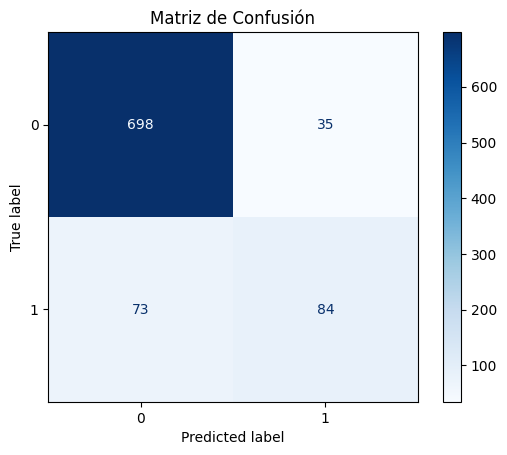

In [15]:
# Se genera una matriz de confusión para el conjunto de test

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Matriz de Confusión")
plt.show()